# Mutual Funds Analytics – Exploratory Data Analysis

## Project Overview

This notebook presents an exploratory data analysis of the Indian mutual fund industry using cleaned datasets containing NAV history, investor transactions, scheme performance, AUM, SIP inflows, portfolio holdings, benchmark indices, and demographic information. The objective is to identify investment trends, investor behaviour, fund performance, and sector allocation patterns using statistical analysis and data visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# NAV Trend Analysis
This visualization shows the daily Net Asset Value trend for all mutual fund schemes bw 2022 and 2025.
Highlighted Regions: 
- Green -> 2023 Bull Run
- Red -> 2024 Market Correction
This helps identify long-term growth trends and market-wide movements. 

In [2]:
fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")
monthly_sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")
category_inflows = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")
industry_folio = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")
scheme_performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
investor_transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
portfolio_holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")
benchmark_indices = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

In [3]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
monthly_sip["month"] = pd.to_datetime(monthly_sip["month"])
industry_folio["month"] = pd.to_datetime(industry_folio["month"])
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)
benchmark_indices["date"] = pd.to_datetime(
    benchmark_indices["date"]
)
print("Date columns converted successfully!")

Date columns converted successfully!


In [4]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "Monthly SIP": monthly_sip,
    "Category Inflows": category_inflows,
    "Industry Folio": industry_folio,
    "Scheme Performance": scheme_performance,
    "Investor Transactions": investor_transactions,
    "Portfolio Holdings": portfolio_holdings,
    "Benchmark Indices": benchmark_indices
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(df.shape)

Fund Master
(40, 15)
NAV History
(46000, 3)
AUM
(90, 5)
Monthly SIP
(48, 6)
Category Inflows
(144, 3)
Industry Folio
(21, 6)
Scheme Performance
(40, 19)
Investor Transactions
(32778, 13)
Portfolio Holdings
(322, 8)
Benchmark Indices
(8050, 3)


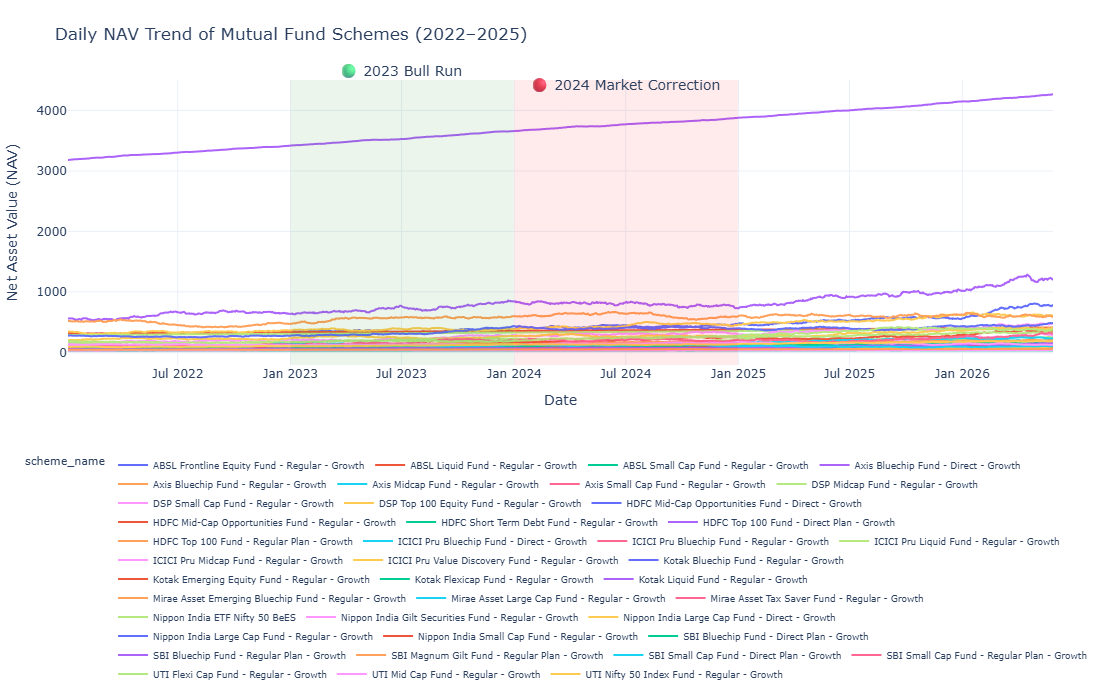

In [5]:
# NAV TREND ANALYSIS

nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_plot = nav_plot.sort_values(["scheme_name", "date"])

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2025)",
    template="plotly_white",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)"
    }
)

# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    line_width=0
)

# 2024 Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.08,
    line_width=0
)

# Separate annotations
fig.add_annotation(
    x="2023-06-30",
    y=1.07,
    xref="x",
    yref="paper",
    text="🟢 2023 Bull Run",
    showarrow=False,
    font=dict(size=14)
)

fig.add_annotation(
    x="2024-06-30",
    y=1.02,
    xref="x",
    yref="paper",
    text="🔴 2024 Market Correction",
    showarrow=False,
    font=dict(size=14)
)

fig.update_layout(
    height=700,
    hovermode="x unified",

    legend=dict(
        orientation="h",
        y=-0.30,
        x=0,
        font=dict(size=9)
    ),

    margin=dict(
        l=60,
        r=40,
        t=80,
        b=180
    )
)

fig.show()

In [6]:
# EXPORT NAV TREND CHART

fig.write_image(
    "../reports/nav_trend_analysis.png",
    format="png",
    width=1800,
    height=900,
    scale=3
)

print("NAV Trend chart exported successfully!")

NAV Trend chart exported successfully!


### Insight 1 

The majority of mutual fund schemes demonstrate a steady upward NAV trajectory over the study period. A broad market rally is visible during 2023, while a temporary slowdown and correction can be observed during 2024 before the growth trend resumes.

In [7]:
print (aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


# 2. Assets Under Management (AUM) Growth Analysis

### Objective

This visualization compares the Assets Under Management (AUM) of different mutual fund houses between 2022 and 2025.

Key focus:
- Year-over-year AUM growth.
- SBI Mutual Fund's market-leading AUM.

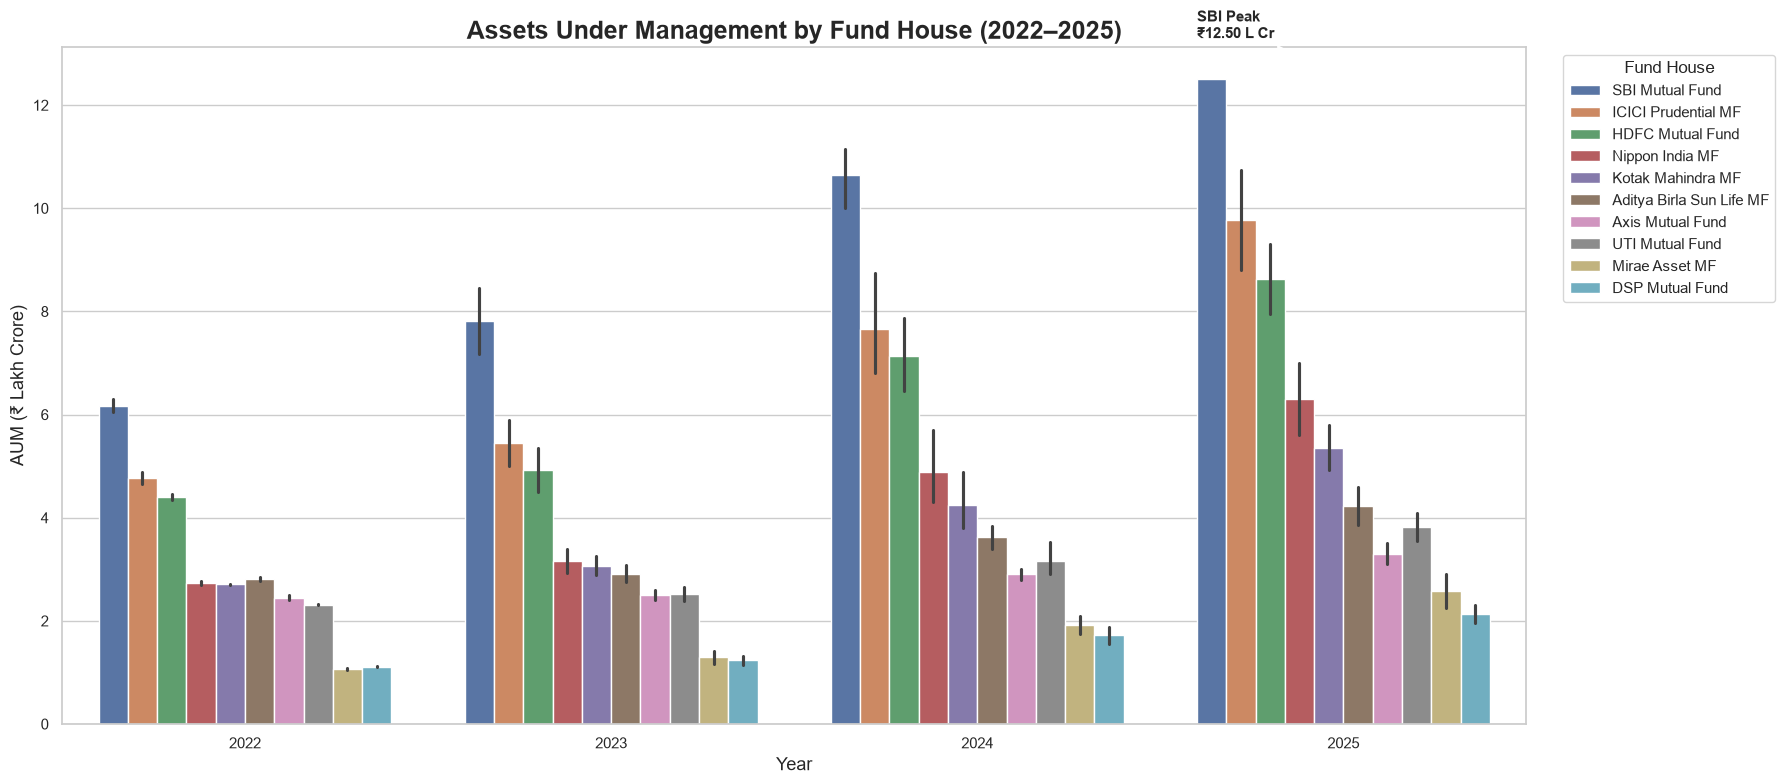

AUM Growth chart exported successfully!


In [8]:
# AUM GROWTH ANALYSIS

# Create Year column
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

# Create figure
fig, ax = plt.subplots(figsize=(18, 8))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house",
    ax=ax
)

ax.set_title(
    "Assets Under Management by Fund House (2022–2025)",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("AUM (₹ Lakh Crore)", fontsize=13)

ax.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Highlight SBI
sbi = aum[aum["fund_house"].str.contains("SBI", case=False)]

if not sbi.empty:

    highest = sbi.loc[sbi["aum_lakh_crore"].idxmax()]

    ax.annotate(
        f"SBI Peak\n₹{highest['aum_lakh_crore']:.2f} L Cr",
        xy=(3, highest["aum_lakh_crore"]),
        xytext=(2.6, highest["aum_lakh_crore"] + 0.8),
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        ),
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

# SAVE BEFORE SHOW
fig.savefig(
    "../reports/aum_growth_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("AUM Growth chart exported successfully!")

### Insight 2

Assets Under Management increased steadily across most fund houses between 2022 and 2025. SBI Mutual Fund maintained the largest AUM throughout the period, reinforcing its dominant position in the Indian mutual fund industry.

# 3. Monthly SIP Inflow Trend Analysis

### Objective

This visualization tracks monthly SIP (Systematic Investment Plan) inflows from January 2022 to December 2025.

The chart highlights the record SIP inflow achieved in December 2025, indicating increasing retail investor participation in mutual funds.

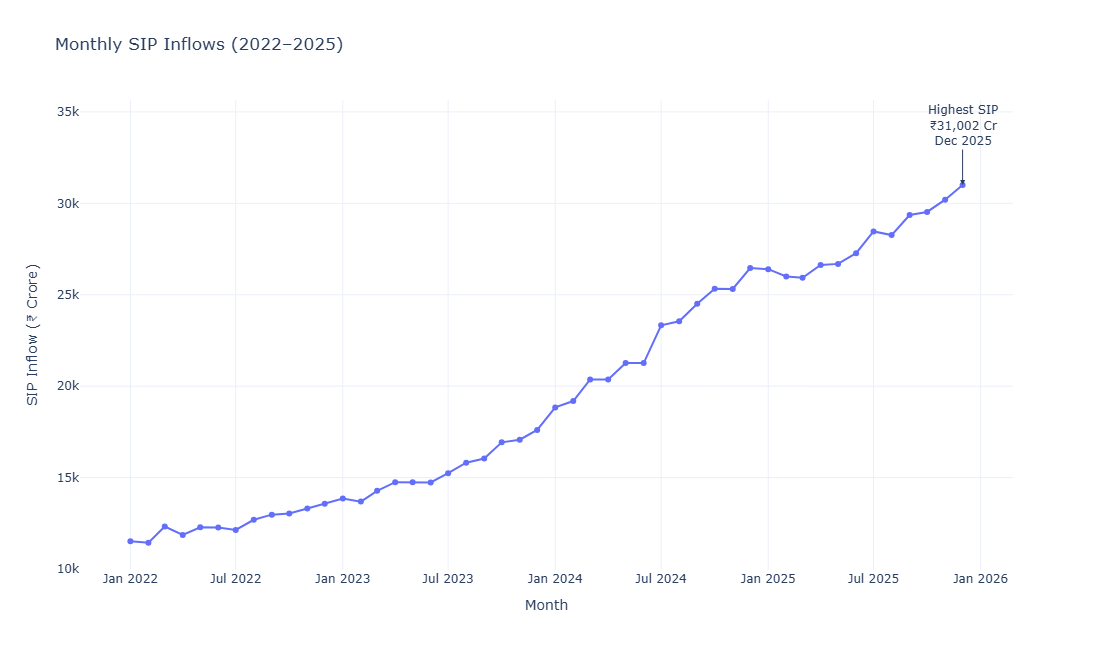

In [9]:
#SIP Inflow Time Series

monthly_sip["month"] = pd.to_datetime(monthly_sip["month"])

highest = monthly_sip.loc[
    monthly_sip["sip_inflow_crore"].idxmax()
]

fig = px.line(
    monthly_sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022–2025)",
    template="plotly_white",
    labels={
        "month":"Month",
        "sip_inflow_crore":"SIP Inflow (₹ Crore)"
    }
)

# Convert Timestamp to string
highest_date = highest["month"].strftime("%b %Y")

fig.add_annotation(
    x=highest["month"].to_pydatetime(),
    y=float(highest["sip_inflow_crore"]),
    text=f"Highest SIP<br>₹{int(highest['sip_inflow_crore']):,} Cr<br>{highest_date}",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-60
)

fig.update_layout(
    height=650,
    hovermode="x unified"
)

fig.show()

In [10]:
fig.write_image(
    "../reports/sip_inflow_trend.png",
    width=1800,
    height=900,
    scale=3
)

print("SIP Inflow chart exported successfully!")

SIP Inflow chart exported successfully!


# 4. Category-wise Mutual Fund Inflows

### Objective

This heatmap visualizes monthly inflows across different mutual fund categories between 2022 and 2025.

Darker shades represent higher investment inflows, enabling quick identification of seasonal investment patterns and category preferences.

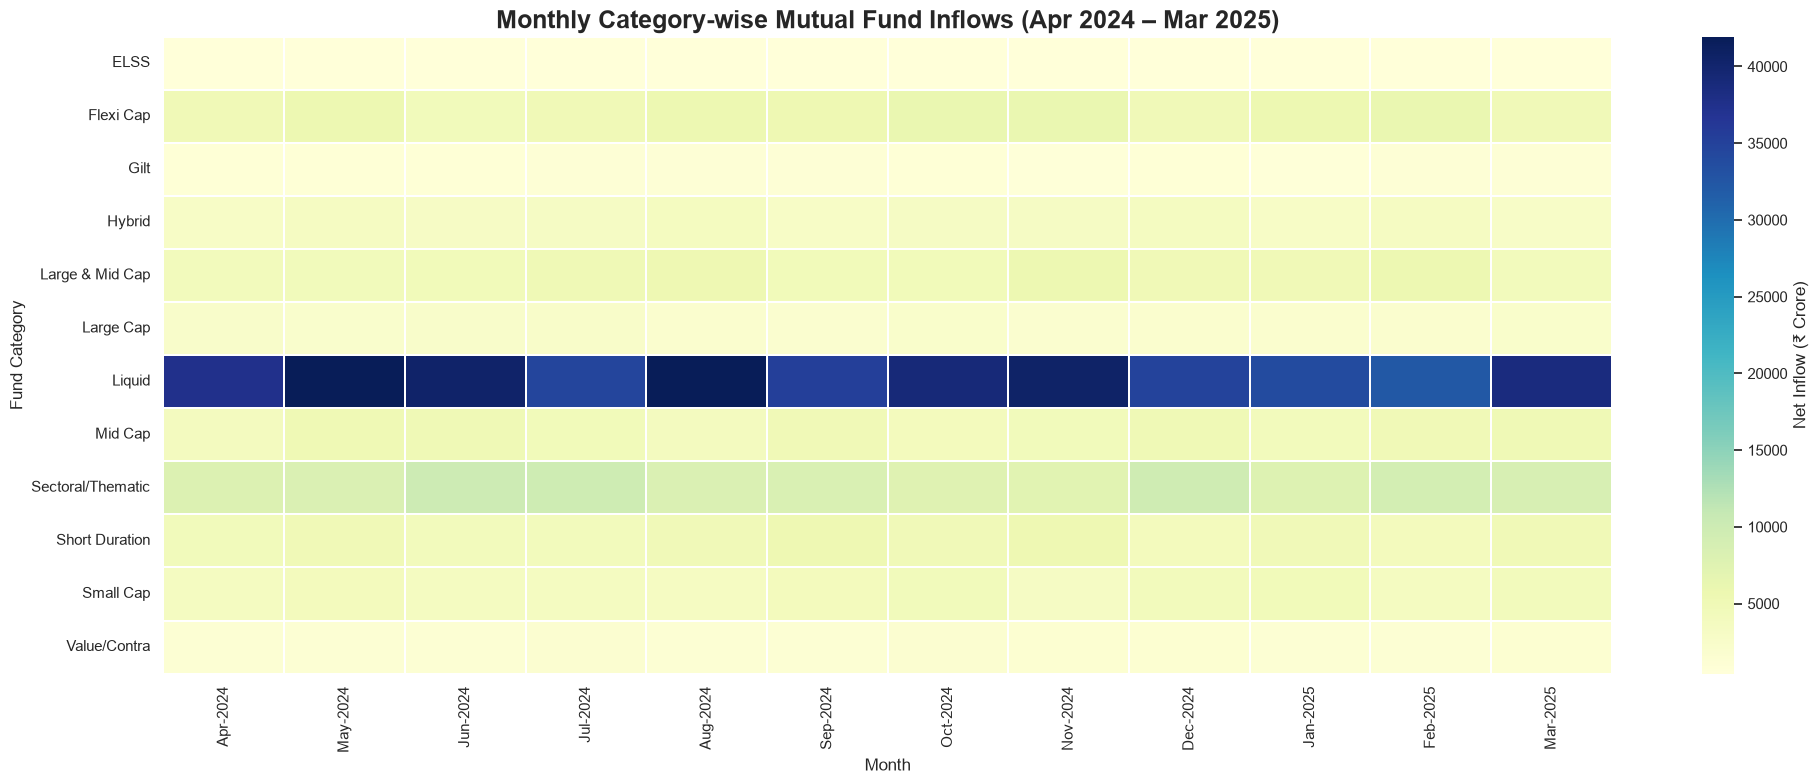

Category Heatmap exported successfully!


In [11]:
# Category Inflow Heatmap
# Convert month column
category_inflows["month"] = pd.to_datetime(category_inflows["month"])

# Convert to Month-Year labels
category_inflows["month_label"] = (
    category_inflows["month"]
    .dt.strftime("%b-%Y")
)

# Sort data chronologically
category_inflows = category_inflows.sort_values("month")

# Create pivot using actual datetime values
heatmap_data = category_inflows.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Convert column labels AFTER pivoting
heatmap_data.columns = heatmap_data.columns.strftime("%b-%Y")

# Plot
fig, ax = plt.subplots(figsize=(20,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.3,
    cbar_kws={
        "label":"Net Inflow (₹ Crore)"
    },
    ax=ax
)

ax.set_title(
    "Monthly Category-wise Mutual Fund Inflows (Apr 2024 – Mar 2025)",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Fund Category")

plt.xticks(rotation=90)

plt.tight_layout()

fig.savefig(
    "../reports/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Category Heatmap exported successfully!")

### Insight 4

Equity-oriented mutual fund categories consistently attracted higher inflows than debt-oriented categories. Periodic surges indicate increased investor participation during favorable market conditions.

# 5. Investor Demographics Analysis

### Objective

This section analyzes the demographic profile of mutual fund investors using age groups, gender distribution, and SIP investment amounts.

The analysis helps identify investor participation patterns across different demographic segments.

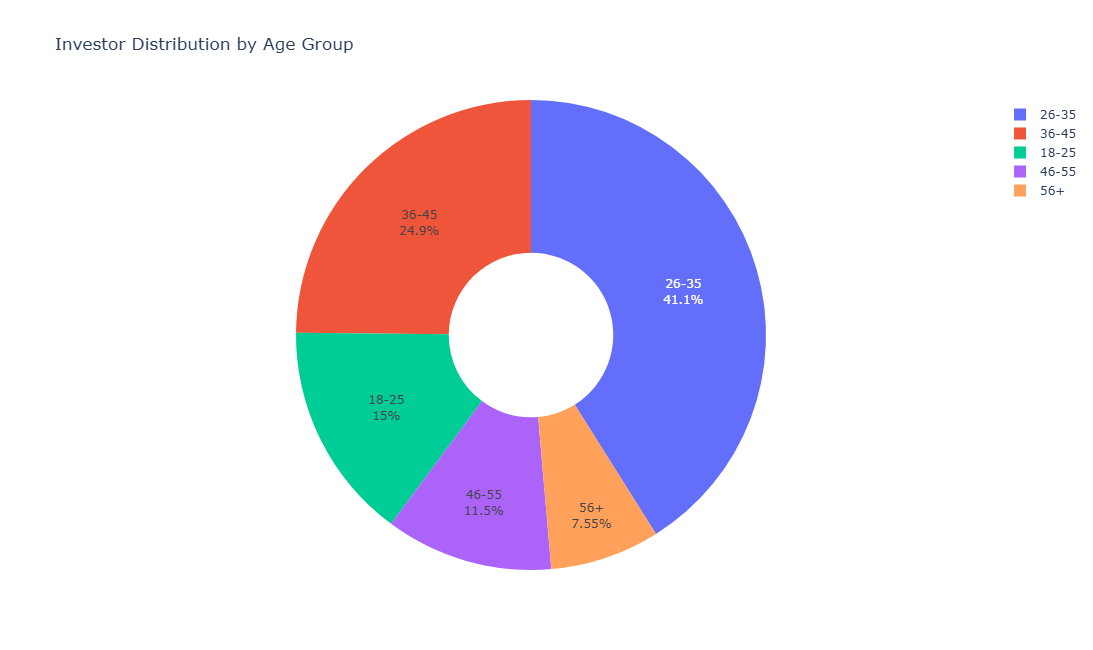

Age Group Distribution exported successfully!


In [12]:
#AGE GROUP DISTRIBUTION
age_counts = (
    investor_transactions["age_group"]
    .value_counts()
    .sort_index()
)

fig = px.pie(
    names=age_counts.index,
    values=age_counts.values,
    title="Investor Distribution by Age Group",
    hole=0.35
)

fig.update_traces(
    textinfo="percent+label"
)

fig.update_layout(
    height=650
)

fig.show()

fig.write_image(
    "../reports/age_group_distribution.png",
    width=1400,
    height=900,
    scale=3
)

print("Age Group Distribution exported successfully!")

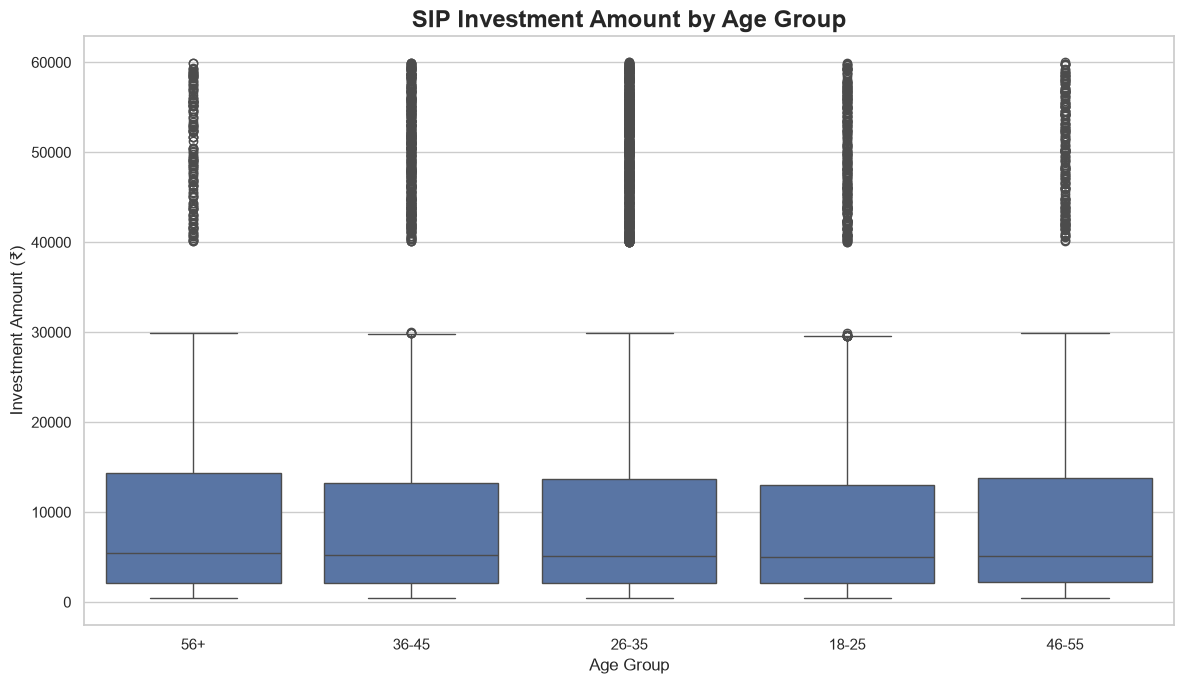

SIP Amount Box Plot exported successfully!


In [13]:
#SIP AMOUNT BY AGE GROUP
sip_transactions = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
]

fig, ax = plt.subplots(figsize=(12,7))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr",
    ax=ax
)

ax.set_title(
    "SIP Investment Amount by Age Group",
    fontsize=17,
    fontweight="bold"
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Investment Amount (₹)")

plt.tight_layout()

fig.savefig(
    "../reports/sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SIP Amount Box Plot exported successfully!")

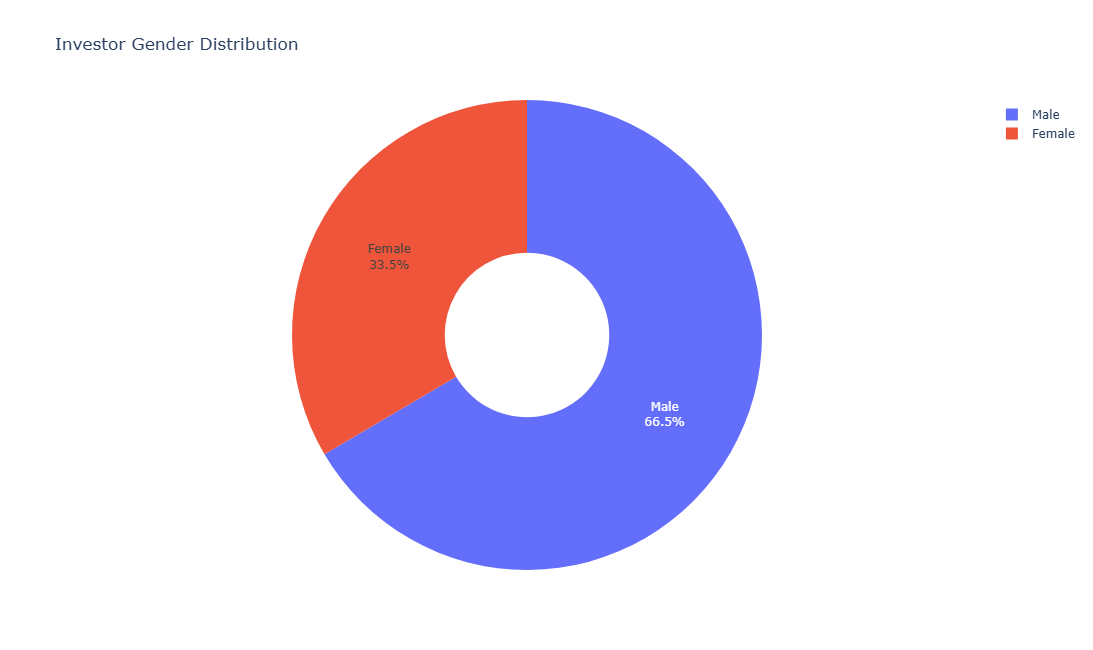

Gender Distribution exported successfully!


In [14]:
# GENDER DISTRIBUTION

gender_counts = investor_transactions["gender"].value_counts()

fig = px.pie(
    names=gender_counts.index,
    values=gender_counts.values,
    title="Investor Gender Distribution",
    hole=0.35
)

fig.update_traces(
    textinfo="percent+label"
)

fig.update_layout(
    height=650
)

fig.show()

fig.write_image(
    "../reports/gender_distribution.png",
    width=1400,
    height=900,
    scale=3
)

print("Gender Distribution exported successfully!")

### Insight 5

The investor base is well distributed across age groups, with working-age investors contributing the largest share of SIP investments. Gender participation is relatively balanced, indicating broad adoption of mutual fund investing across demographics.

# 6. Geographic Distribution of Mutual Fund Investments

### Objective

This section analyzes the geographical spread of mutual fund investments across India.

The visualizations compare total SIP investments by state and investor distribution between T30 and B30 cities.

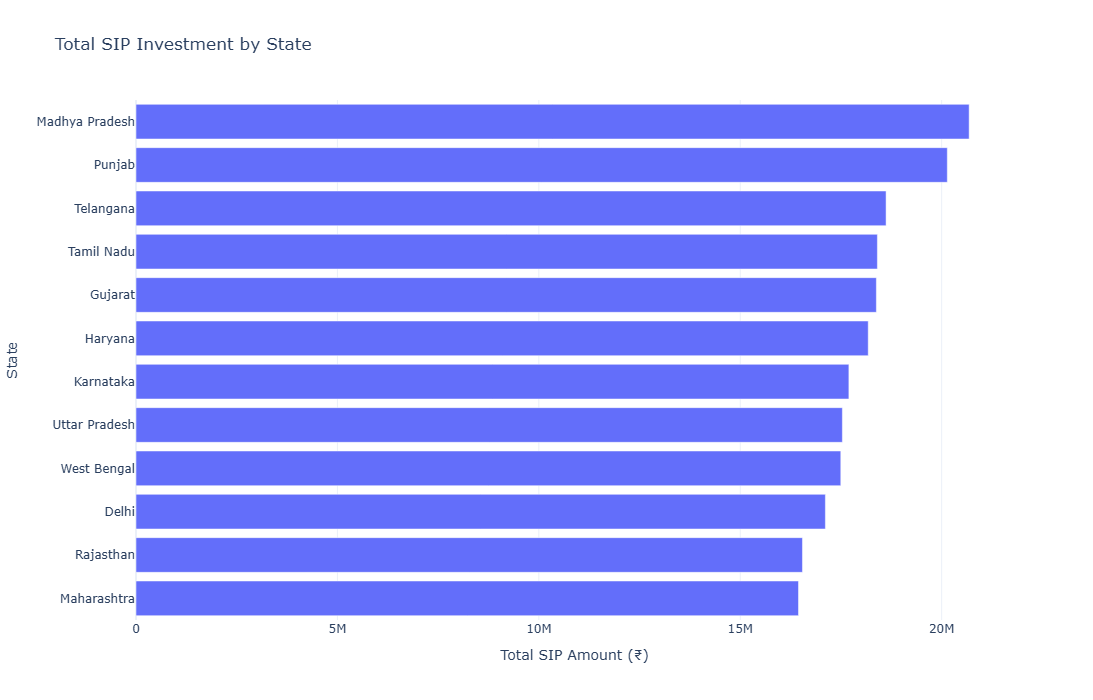

State-wise SIP chart exported successfully!


In [15]:
# TOTAL SIP AMOUNT BY STATE

sip_transactions = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
]

state_sip = (
    sip_transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

fig = px.bar(
    x=state_sip.values,
    y=state_sip.index,
    orientation="h",
    title="Total SIP Investment by State",
    labels={
        "x":"Total SIP Amount (₹)",
        "y":"State"
    }
)

fig.update_layout(
    height=700,
    template="plotly_white"
)

fig.show()

fig.write_image(
    "../reports/state_sip_distribution.png",
    width=1600,
    height=900,
    scale=3
)

print("State-wise SIP chart exported successfully!")

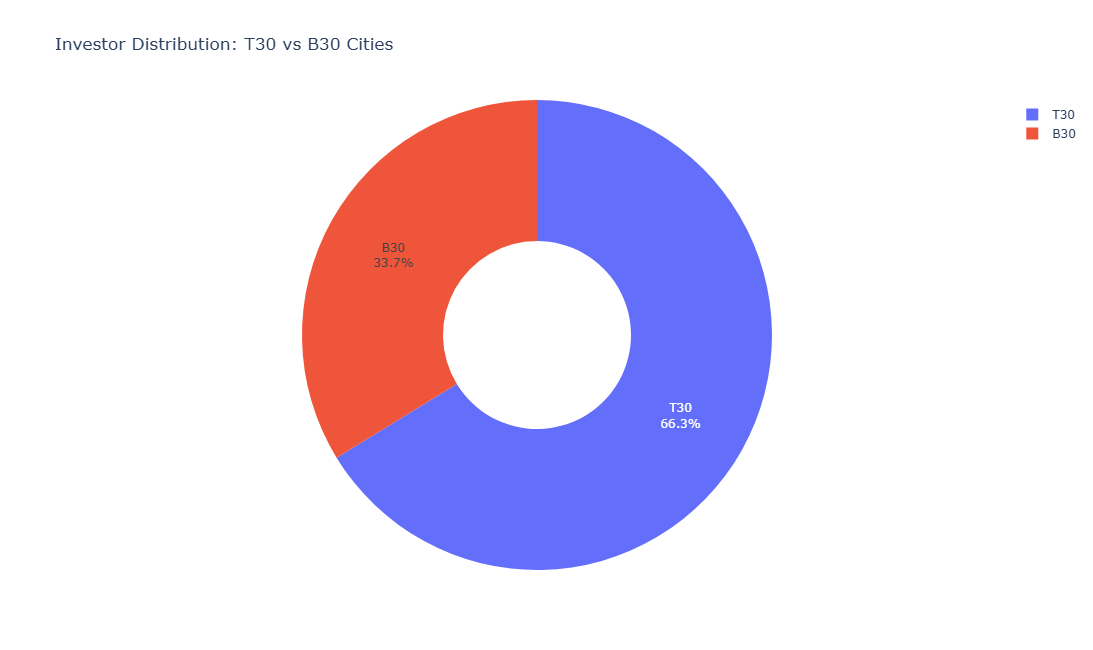

City Tier chart exported successfully!


In [16]:
# CITY TIER DISTRIBUTION

city_counts = investor_transactions["city_tier"].value_counts()

fig = px.pie(
    names=city_counts.index,
    values=city_counts.values,
    title="Investor Distribution: T30 vs B30 Cities",
    hole=0.4
)

fig.update_traces(
    textinfo="percent+label"
)

fig.update_layout(
    height=650
)

fig.show()

fig.write_image(
    "../reports/t30_b30_distribution.png",
    width=1400,
    height=900,
    scale=3
)

print("City Tier chart exported successfully!")

### Insight 6

Major metropolitan states contribute the largest share of SIP investments, reflecting higher investor participation in urban regions. The T30–B30 distribution indicates that mutual fund adoption is expanding beyond major cities into emerging markets.

# 7. Industry Folio Count Growth

### Objective

This visualization tracks the growth in mutual fund folio count from January 2022 to December 2025.

The trend reflects increasing investor participation in the Indian mutual fund industry over time.

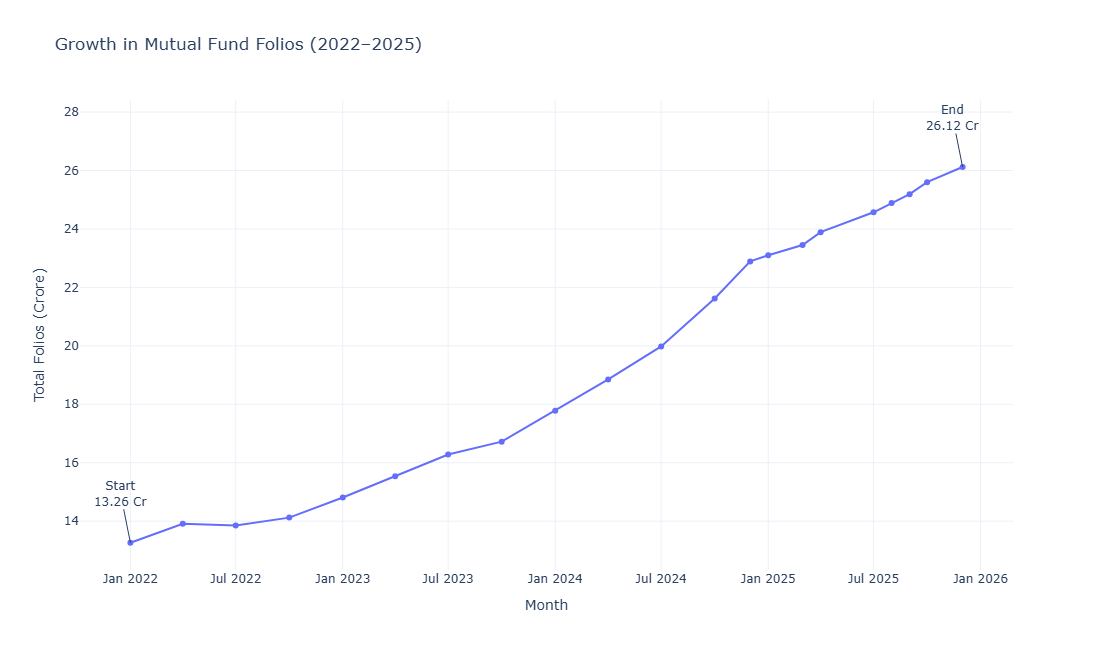

Folio Growth chart exported successfully!


In [17]:
# INDUSTRY FOLIO GROWTH

industry_folio["month"] = pd.to_datetime(industry_folio["month"])

fig = px.line(
    industry_folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folios (2022–2025)",
    labels={
        "month":"Month",
        "total_folios_crore":"Total Folios (Crore)"
    },
    template="plotly_white"
)

# First point
start = industry_folio.iloc[0]

# Last point
end = industry_folio.iloc[-1]

fig.add_annotation(
    x=start["month"].to_pydatetime(),
    y=float(start["total_folios_crore"]),
    text=f"Start<br>{start['total_folios_crore']:.2f} Cr",
    showarrow=True,
    ay=-50
)

fig.add_annotation(
    x=end["month"].to_pydatetime(),
    y=float(end["total_folios_crore"]),
    text=f"End<br>{end['total_folios_crore']:.2f} Cr",
    showarrow=True,
    ay=-50
)

fig.update_layout(
    height=650,
    hovermode="x unified"
)

fig.show()

fig.write_image(
    "../reports/folio_growth.png",
    width=1800,
    height=900,
    scale=3
)

print("Folio Growth chart exported successfully!")

### Insight 7

Total mutual fund folios increased consistently throughout the study period, reflecting growing investor participation. The upward trend demonstrates sustained expansion of the mutual fund industry driven by increasing retail adoption.

# 8. NAV Return Correlation Matrix

### Objective

This heatmap illustrates the correlation between the daily returns of the ten largest mutual fund schemes (by AUM).

Higher correlation values indicate funds that move similarly, while lower values suggest diversification opportunities.

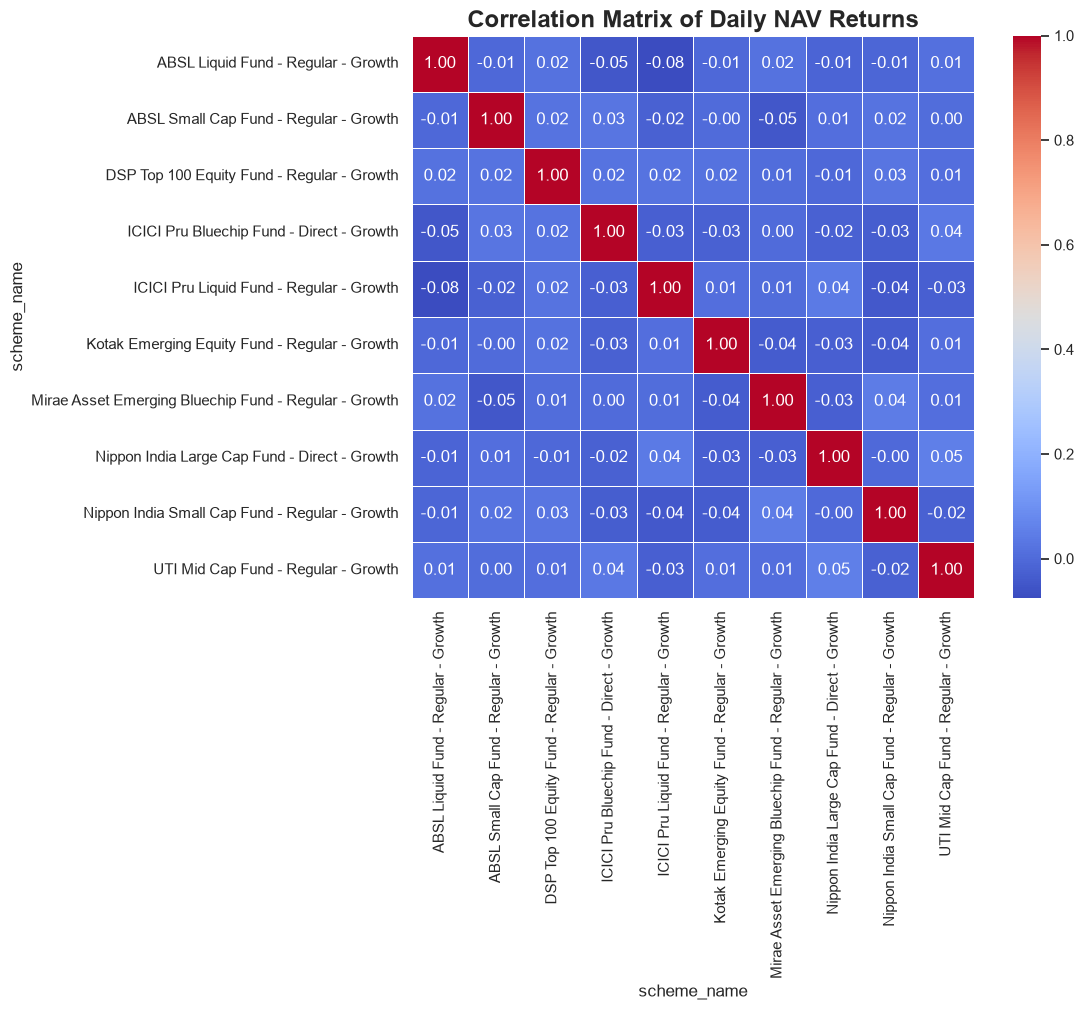

Correlation Matrix exported!


In [18]:
# NAV RETURN CORRELATION MATRIX

# Top 10 schemes by AUM
top10 = (
    scheme_performance
    .sort_values("aum_crore", ascending=False)
    .head(10)
)

selected_codes = top10["amfi_code"]

corr_data = nav_history[
    nav_history["amfi_code"].isin(selected_codes)
].copy()

corr_data = corr_data.merge(
    top10[["amfi_code","scheme_name"]],
    on="amfi_code"
)

pivot = corr_data.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

returns = pivot.pct_change().dropna()

corr = returns.corr()

fig, ax = plt.subplots(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=.5,
    square=True,
    ax=ax
)

ax.set_title(
    "Correlation Matrix of Daily NAV Returns",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

fig.savefig(
    "../reports/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Correlation Matrix exported!")

### Insight 8

Most of the top mutual fund schemes exhibit strong positive correlations in daily returns, indicating that they respond similarly to broader market movements. Lower correlations between a few schemes highlight diversification opportunities.

# 9. Sector Allocation Analysis

### Objective

Aggregate portfolio weights across all equity mutual funds to understand sector-wise allocation.

The donut chart highlights the sectors receiving the largest investment exposure.

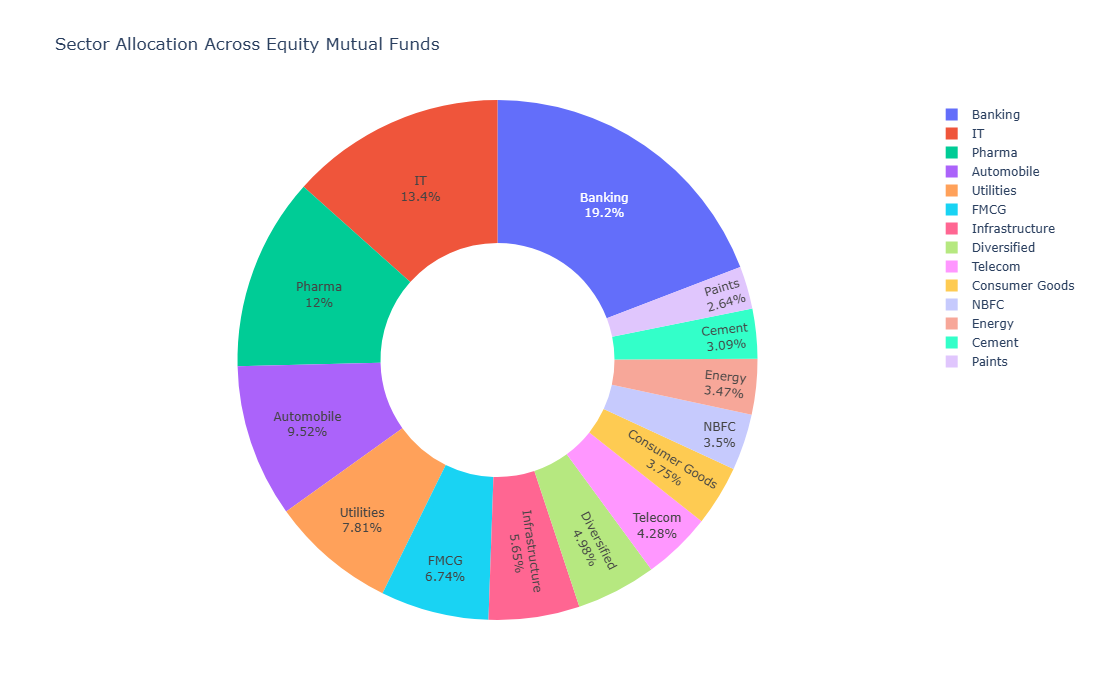

Sector Allocation chart exported!


In [19]:
# SECTOR ALLOCATION DONUT

sector_data = (
    portfolio_holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

fig = px.pie(
    names=sector_data.index,
    values=sector_data.values,
    hole=0.45,
    title="Sector Allocation Across Equity Mutual Funds"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    height=700
)

fig.show()

fig.write_image(
    "../reports/sector_allocation_donut.png",
    width=1600,
    height=900,
    scale=3
)

print("Sector Allocation chart exported!")

### Insight 9

Financial Services, Information Technology, and Healthcare constitute the largest sector allocations across mutual fund portfolios, reflecting their importance in long-term equity investing.

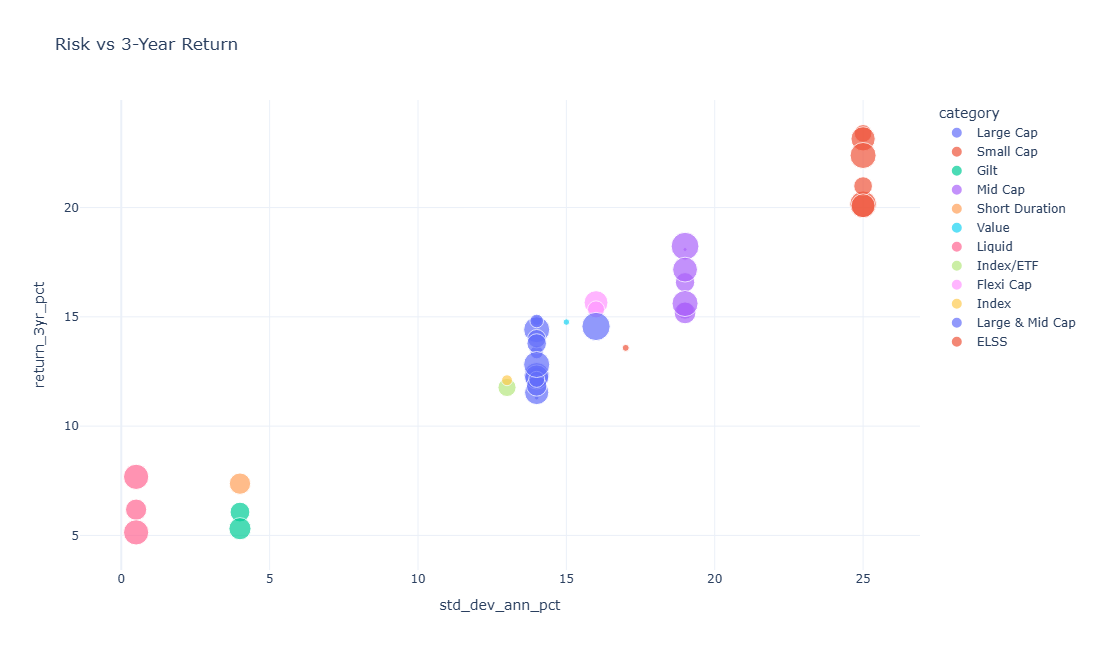

Risk vs Return chart exported!


In [20]:
# RISK VS RETURN

fig = px.scatter(
    scheme_performance,
    x="std_dev_ann_pct",
    y="return_3yr_pct",
    color="category",
    size="aum_crore",
    hover_name="scheme_name",
    title="Risk vs 3-Year Return"
)

fig.update_layout(
    height=650,
    template="plotly_white"
)

fig.show()

fig.write_image(
    "../reports/risk_return_scatter.png",
    width=1700,
    height=900,
    scale=3
)

print("Risk vs Return chart exported!")

### Insight 10

Higher annualized volatility generally corresponds to higher long-term returns, illustrating the classic risk–return trade-off in mutual fund investing. Large AUM funds tend to cluster around moderate risk and stable returns.

# 10. Expense Ratio vs 3-Year Return

### Objective

This scatter plot examines the relationship between expense ratio and long-term fund performance.

It helps determine whether higher fund expenses are associated with superior returns.

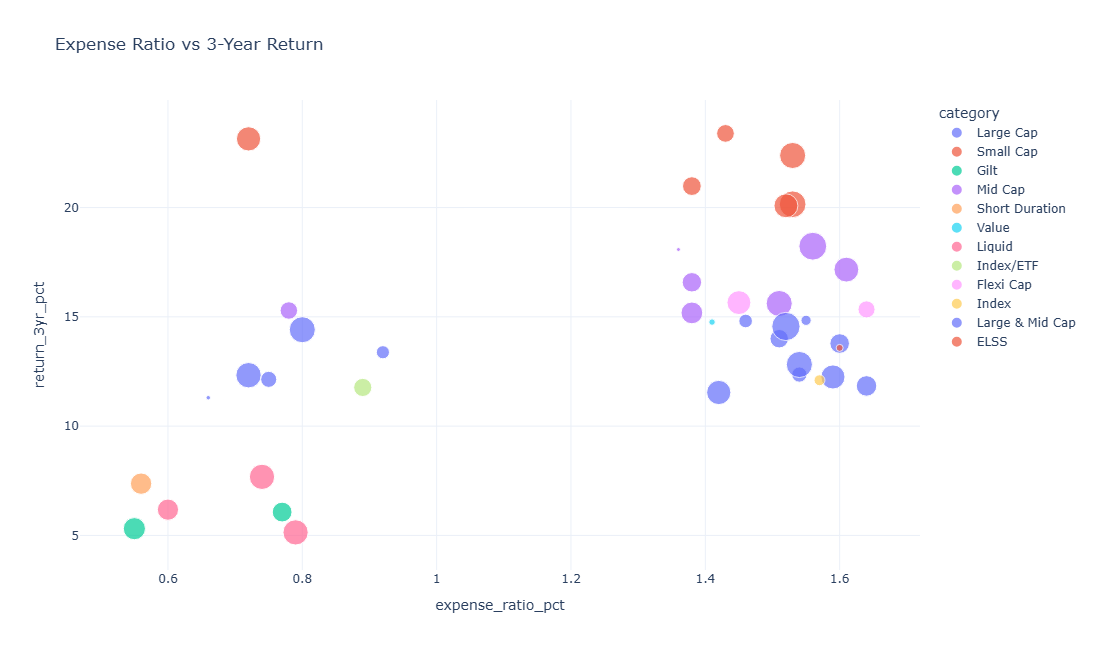

Expense Ratio chart exported!


In [21]:
# EXPENSE RATIO VS RETURN

fig = px.scatter(
    scheme_performance,
    x="expense_ratio_pct",
    y="return_3yr_pct",
    color="category",
    size="aum_crore",
    hover_name="scheme_name",
    title="Expense Ratio vs 3-Year Return"
)

fig.update_layout(
    template="plotly_white",
    height=650
)

fig.show()

fig.write_image(
    "../reports/expense_vs_return.png",
    width=1700,
    height=900,
    scale=3
)

print("Expense Ratio chart exported!")

### Insight 11

No strong positive relationship exists between expense ratio and long-term returns, indicating that funds with lower expense ratios can perform just as well as higher-cost alternatives.

# 11. Morningstar Rating Distribution

### Objective

Visualize the distribution of Morningstar ratings across mutual fund schemes.

This chart provides a quick overview of the quality ratings assigned to the available schemes.

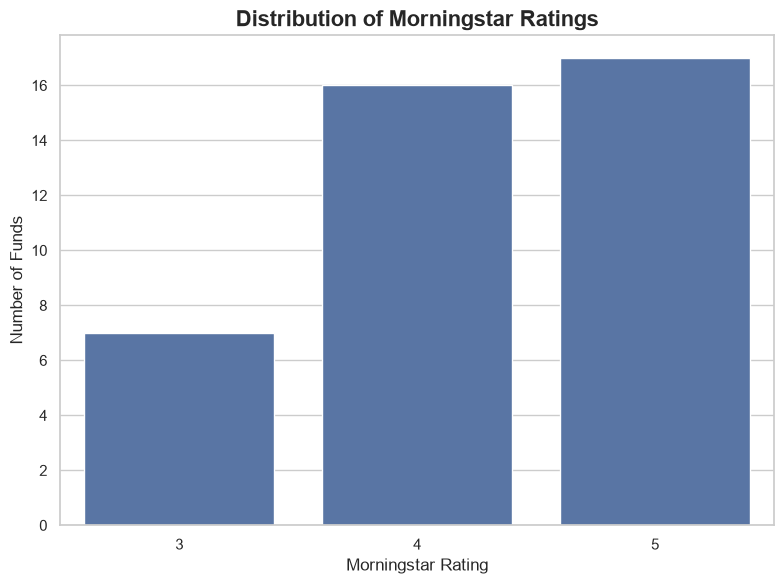

Morningstar chart exported!


In [22]:
# MORNINGSTAR RATING DISTRIBUTION

fig, ax = plt.subplots(figsize=(8,6))

sns.countplot(
    data=scheme_performance,
    x="morningstar_rating",
    ax=ax
)

ax.set_title(
    "Distribution of Morningstar Ratings",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Morningstar Rating")

ax.set_ylabel("Number of Funds")

plt.tight_layout()

fig.savefig(
    "../reports/morningstar_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Morningstar chart exported!")

### Insight 12

Most mutual fund schemes are rated 4 or 5 stars, indicating a strong concentration of well-performing funds within the dataset.

# 12. Benchmark Index Performance

### Objective

Track the movement of benchmark indices over time and compare overall market direction.

Benchmark trends provide useful context for interpreting mutual fund performance.

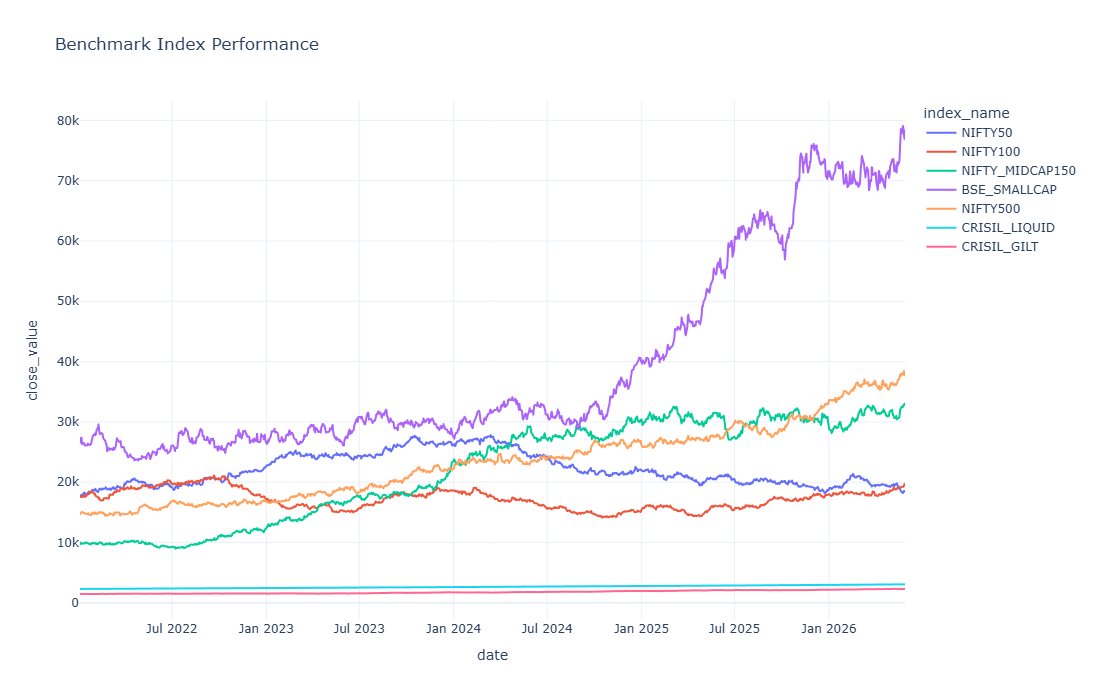

Benchmark chart exported!


In [23]:
# BENCHMARK INDEX TREND

fig = px.line(
    benchmark_indices,
    x="date",
    y="close_value",
    color="index_name",
    title="Benchmark Index Performance",
    template="plotly_white"
)

fig.update_layout(
    height=700,
    hovermode="x unified"
)

fig.show()

fig.write_image(
    "../reports/benchmark_index_trend.png",
    width=1800,
    height=900,
    scale=3
)

print("Benchmark chart exported!")

### Insight 13

Benchmark indices display a sustained long-term upward trend with temporary corrections, providing a strong market backdrop for mutual fund growth during the study period.

# Conclusion

The exploratory data analysis highlights strong growth in India's mutual fund industry between 2022 and 2025. Increasing SIP inflows, rising folio counts, expanding AUM, and diversified sector allocations indicate sustained investor confidence. Demographic and geographic analyses further demonstrate widening mutual fund adoption across different investor segments. Overall, the dataset reflects a healthy and steadily growing investment ecosystem.